# Dataset 1 Analysis: FEIS



In [1]:
from pathlib import Path
import sys
import pandas as pd
from IPython.display import Image, Markdown, display

def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / 'scripts' / 'eeg_dataset_analysis_lib.py').exists():
            return candidate
    raise RuntimeError('Could not locate project root containing scripts/eeg_dataset_analysis_lib.py')

PROJECT_ROOT = find_project_root(Path.cwd())
sys.path.insert(0, str(PROJECT_ROOT / 'scripts'))
from eeg_dataset_analysis_lib import analyze_feis


In [2]:
bundle = analyze_feis()
summary = bundle.summary
assets = bundle.assets
summary['dataset_name'], summary['subject_folder_count']

('FEIS', 23)

## 一、数据集整体概览

In [3]:
overview_df = pd.DataFrame(summary['overview_rows'], columns=['subject', 'trial_count', 'label_count', 'has_full_eeg'])
display(overview_df)
display(Markdown(f"- irregular subjects: `{summary['irregular_subjects']}`"))
display(Markdown(f"- representative subject: `{summary['representative_subject']}`"))
display(Markdown(f"- channels: `{', '.join(summary['channel_names'])}`"))


,subject,trial_count,label_count,has_full_eeg
0,01,160,16,yes
1,02,160,16,yes
2,03,160,16,yes
3,04,160,16,yes
4,05,160,16,yes
5,06,160,16,yes
6,07,160,16,yes
7,08,160,16,yes
8,09,160,16,yes
9,10,160,16,yes


- irregular subjects: `['12', 'chinese-1', 'chinese-2']`

- representative subject: `01`

- channels: `F3, FC5, AF3, F7, T7, P7, O1, O2, P8, T8, F8, AF4, FC6, F4`

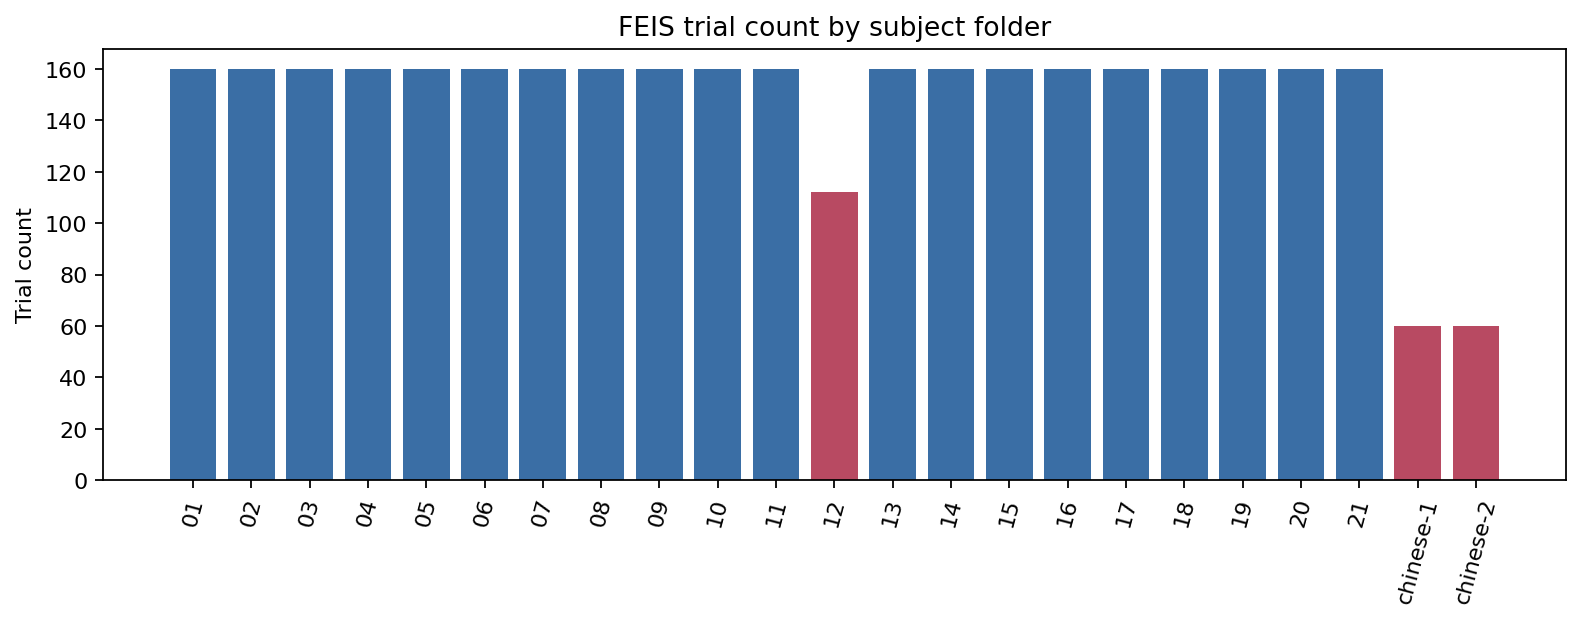

In [4]:
display(Image(filename=assets['trial_counts']))

## 二、实验范式分析

In [7]:
stage_counts_df = pd.DataFrame(list(summary['representative_stage_counts'].items()), columns=['stage', 'samples'])
stage_counts_df['approx_seconds'] = stage_counts_df['samples'] / 256.0
display(stage_counts_df)
display(Markdown('从 `full_eeg.csv` 的 Stage 列可以直接恢复 trial 顺序：`stimuli -> articulators -> thinking -> speaking -> resting`。'))


,stage,samples,approx_seconds
0,articulators,40960,160.0
1,resting,204800,800.0
2,speaking,204800,800.0
3,stimuli,204800,800.0
4,thinking,204800,800.0


从 `full_eeg.csv` 的 Stage 列可以直接恢复 trial 顺序：`stimuli -> articulators -> thinking -> speaking -> resting`。

Resting / resting phase：静息基线。
Stimuli phase：受试看到/听到音素或音节提示，"heard/listening"。
Articulators phase：README 说明这里其实是 1 秒 fixation point。
Thinking phase：受试在脑海中想象说出该音素/音节。
Speaking phase：受试实际说出该音素/音节，同时有录音。

articulators: 40960 点，约 160.0 秒，160 / 160 = 1 秒 / trial
resting: 204800 点，约 800.0 秒，800 / 160 = 5 秒 / trial
speaking: 204800 点，约 800.0 秒，800 / 160 = 5 秒 / trial
stimuli: 204800 点，约 800.0 秒，800 / 160 = 5 秒 / trial
thinking: 204800 点，约 800.0 秒，800 / 160 = 5 秒 / trial

## 三、单受试者深度分析

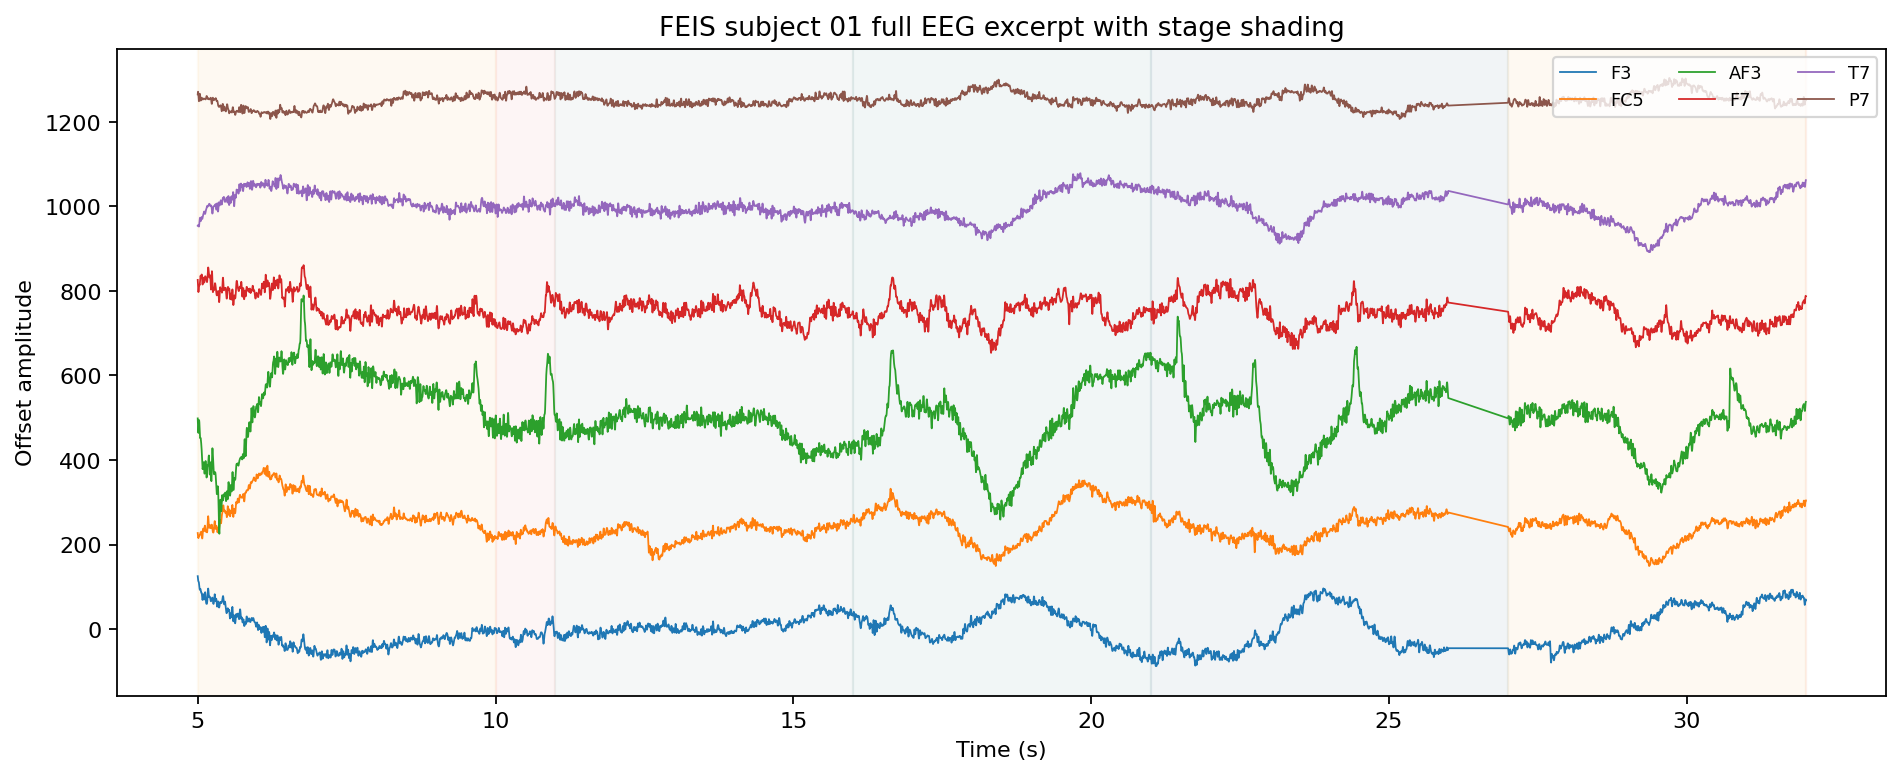

In [8]:
display(Image(filename=assets['waveform']))

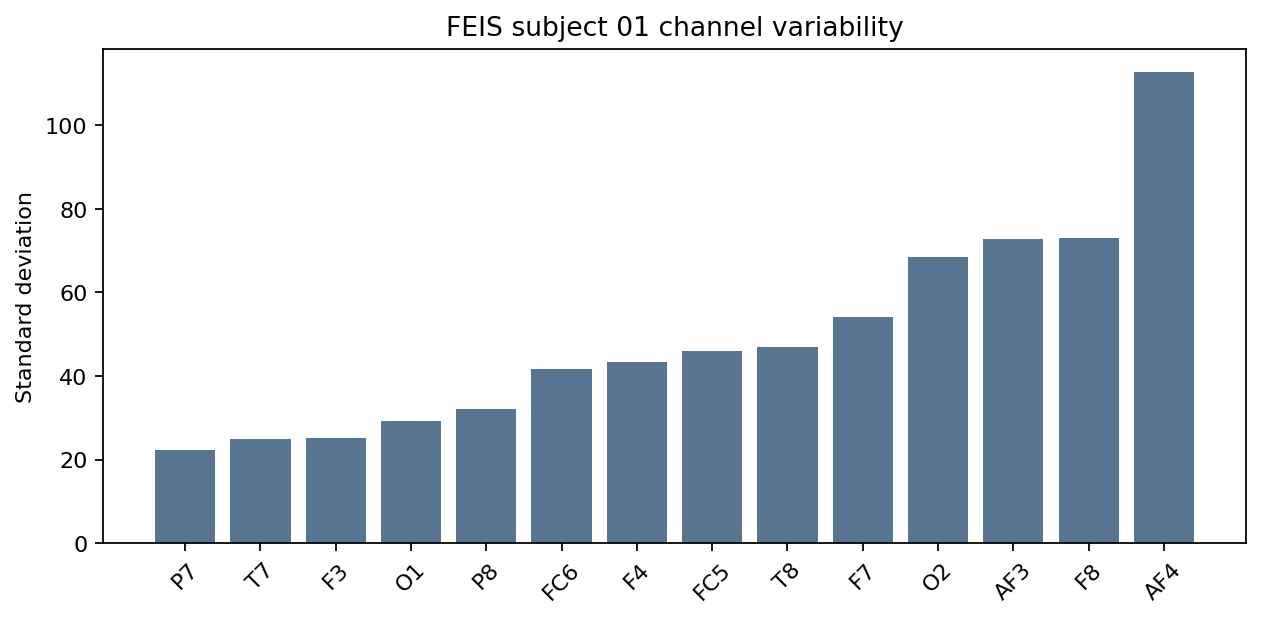

In [9]:
display(Image(filename=assets['channel_std']))

## 四、事件与标签分析

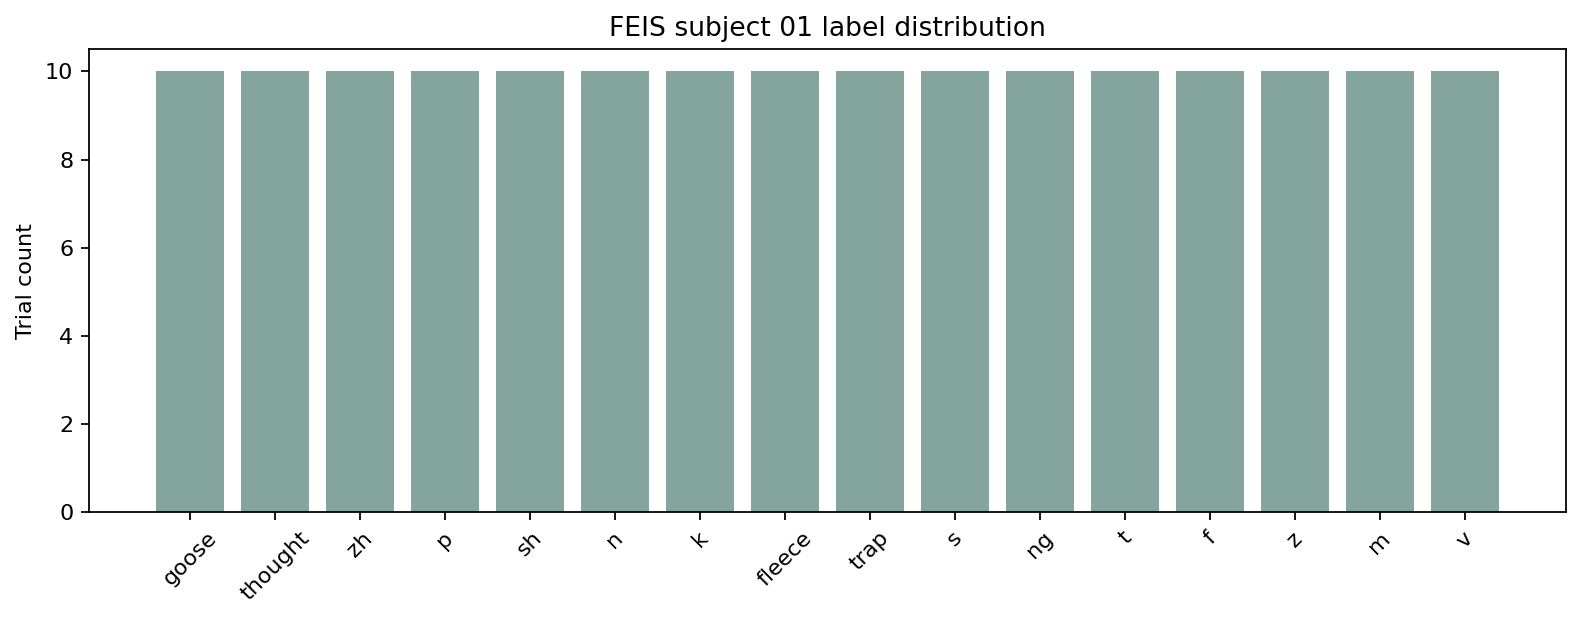

,task,judgment
0,phoneme_classification,Yes - strong fit
1,word_classification,Weak - labels are mostly phoneme/syllable-leve...
2,speech_decoding,Moderate for imagined-vs-spoken/phoneme-level ...
3,speech_reconstruction,Weak foundation only


In [10]:
display(Image(filename=assets['labels']))
fit_df = pd.DataFrame(summary['research_fit'].items(), columns=['task', 'judgment'])
display(fit_df)


## 五、与研究目标的匹配度评估

In [11]:
for note in summary['data_quality_notes']:
    print('-', note)

print('\nKey conclusion: FEIS is a strong pilot set for imagined phoneme classification, but a weak foundation for speech reconstruction.')


- 每个英文被试大多有 160 个 trial，但 subject 12 只有 112 个 trial，是当前下载包里最明显的不规则个体。
- full_eeg.csv 的 Stage / Epoch / Label 列为每个时间点直接给出标签，对齐非常方便。
- 两个 chinese supplementary 文件夹使用了另一套列名（Channel 1-14, Event Id, Event Date, Event Duration），与英文主集 schema 不完全一致。
- 当前发布的是派生 CSV，而不是带 trigger 的原始 EEG 流；重新做更细粒度事件切分的自由度有限。

Key conclusion: FEIS is a strong pilot set for imagined phoneme classification, but a weak foundation for speech reconstruction.
